## 🔍 Parte 1: Análise Exploratória na Camada Silver
Nesta etapa, responderemos às 3 primeiras perguntas de negócio utilizando os dados limpos e tipados da tabela `silver_viagem`.

In [3]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E AUXILIARES DO PROJETO
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import text

# Módulos customizados de infraestrutura e segurança (conforme Seção 5.2 do PDF)
import banco
from config import carregar_env

# ==============================================================================
# 2. DEFINIÇÃO DE PALETAS E CORES PADRONIZADAS (DATAVIZ EXECUTIVO)
# ==============================================================================
# Paletas globais para consistência visual nas 6 análises da Camada Gold
PALETA_RANKING = ["#1b365d", "#28538b", "#3470b8", "#5391cf", "#8ab8e6"]
PALETA_CATEGORICA = ["#1b365d", "#2c3e50", "#16a085", "#f39c12", "#8e44ad"]

# Dicionário de cores semânticas (comparação financeiro/executiva)
CORES_PADRAO = {
    'Custo Total Gerado': '#b0bec5',      # Cinza claro para referência/teto
    'Total Efetivamente Pago': '#1565c0', # Azul escuro para o desembolso real
    'Unico': '#1b365d'                    # Azul corporativo para métrica única
}

# ==============================================================================
# 3. CONFIGURAÇÃO GLOBAL DE ESTILO DO MATPLOTLIB / SEABORN
# ==============================================================================
# Estilo limpo com foco no dado (Maximização do Data-Ink Ratio)
sns.set_theme(style="white", palette=PALETA_RANKING)

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['figure.figsize'] = (12, 6)

# Tipografia e Hierarquia de Títulos (Garante clareza visual - Critério 7)[cite: 1]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelpad'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Remoção de Bordas Desnecessárias (Redução de Ruído Visual)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.left'] = True

# ==============================================================================
# 4. INICIALIZAÇÃO DE VARIÁVEIS E CONEXÃO COM BANCO DE DADOS
# ==============================================================================
# Carrega credenciais de forma segura via .env (Boas Práticas - Seção 4)[cite: 3]
carregar_env()

# Tenta obter a engine do SQLAlchemy de forma flexível (evita erros de nomenclatura no banco.py)
try:
    engine = banco.obter_engine()
except AttributeError:
    # Fallback caso a função no seu banco.py se chame conectar() ou similiar[cite: 1, 3]
    engine = banco.conectar()

print("✔ Ambiente configurado e conectado ao banco PostgreSQL/MySQL com sucesso!")

✔ Ambiente configurado e conectado ao banco PostgreSQL/MySQL com sucesso!


--- TABELA: Top 5 Órgãos com Maior Custo Total ---


,orgao,custo_total
0,Ministério da Justiça e Segurança Pública,"R$ 486,933,121.65"
1,Ministério da Defesa,"R$ 156,070,304.49"
2,Ministério da Educação,"R$ 111,291,349.34"
3,Ministério do Meio Ambiente e Mudança do Clima,"R$ 49,697,710.16"
4,Ministério da Previdência Social,"R$ 40,417,309.06"


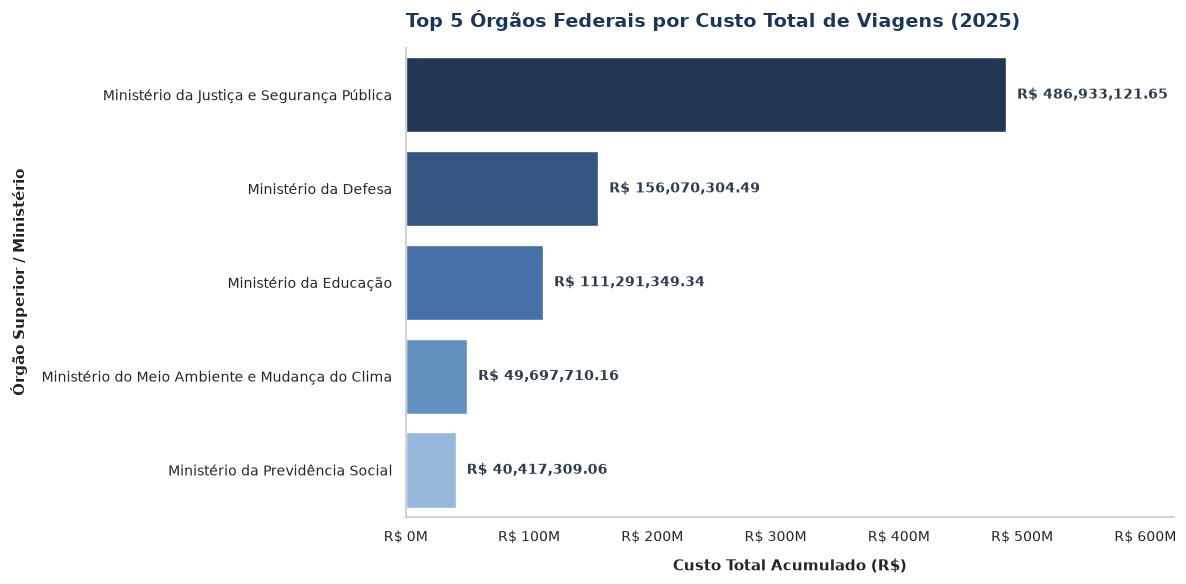


💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:
O órgão com o maior dispêndio em viagens a serviço é o 'Ministério da Justiça e Segurança Pública', 
acumulando um custo total de R$ 486,933,121.65 no período analisado.


In [4]:
# ==============================================================================
# PERGUNTA 1: Quais são os 5 órgãos com maior custo total de viagens?
# OBJETIVO: Consulta analítica na camada Silver com gráfico de ranking horizontal.
# ==============================================================================

# 1. Consulta SQL: Agregação de custo por órgão superior com arredondamento monetário
sql_q1 = """
SELECT 
    nome_orgao_superior AS orgao,
    ROUND(SUM(valor_total), 2) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
"""

# 2. Execução da Consulta e Carregamento no DataFrame
with engine.connect() as conn:
    df_q1 = pd.read_sql(text(sql_q1), con=conn)

# 3. Exibição da Tabela Formatada no Console/Notebook
print("--- TABELA: Top 5 Órgãos com Maior Custo Total ---")
try:
    display(df_q1.style.format({'custo_total': 'R$ {:,.2f}'}))
except NameError:
    print(df_q1)

# 4. Construção do Gráfico Padronizado
fig, ax = plt.subplots(figsize=(12, 6))

# Criação do gráfico de barras horizontais usando a paleta do projeto
bars = sns.barplot(
    data=df_q1, 
    x='custo_total', 
    y='orgao', 
    hue='orgao', 
    palette=PALETA_RANKING,  # Aplicação da paleta executiva padronizada
    legend=False, 
    ax=ax
)

# 5. Customização de Títulos e Eixos Nomeados [Atendimento rigoroso ao Critério 7 do PDF]
ax.set_title("Top 5 Órgãos Federais por Custo Total de Viagens (2025)", loc='left', color='#1b365d', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Custo Total Acumulado (R$)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Órgão Superior / Ministério", fontsize=11, fontweight='bold', labelpad=10)

# Formatação limpa dos eixos e remoção de bordas superiores e direitas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Formatação dos valores numéricos do eixo X no padrão de milhões
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:,.0f}M'))

# 6. Inserção dos Rótulos de Dados diretamente nas barras (Precisão Analítica)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        valor_formatado = f'R$ {width:,.2f}'
        ax.annotate(
            valor_formatado, 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center', 
            xytext=(8, 0),  # Deslocamento de 8 pontos para respiro visual
            textcoords='offset points', 
            fontweight='bold', 
            fontsize=10,
            color='#2c3e50'
        )

# Expansão do limite X para garantir que o texto das anotações não seja cortado
ax.set_xlim(0, df_q1['custo_total'].max() * 1.28)

plt.tight_layout()


# Crie a pasta automaticamente para armazenar os gráficos
os.makedirs("graficos", exist_ok=True)

# Na hora de salvar cada gráfico, coloque o prefixo 'graficos/':
plt.savefig("graficos/grafico_1_top_5_orgaos_federais_por_custo_total_de_viagens.png", dpi=300, bbox_inches='tight')
plt.show()

# 7. Resposta Analítica / Insight [Atendimento ao Critério 6 e Seção 5.7 do PDF]
orgao_lider = df_q1.iloc[0]['orgao']
custo_lider = df_q1.iloc[0]['custo_total']
print(f"\n💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:")
print(f"O órgão com o maior dispêndio em viagens a serviço é o '{orgao_lider}', ")
print(f"acumulando um custo total de R$ {custo_lider:,.2f} no período analisado.")


--- TABELA: Top 3 Destinos com Maior Custo Médio por Viagem ---


,destino_principal,custo_medio
0,Cologne/Alemanha,"R$ 50,847.25"
1,Planalto/RS,"R$ 47,156.89"
2,Visakhapatnam/Índia,"R$ 43,609.63"


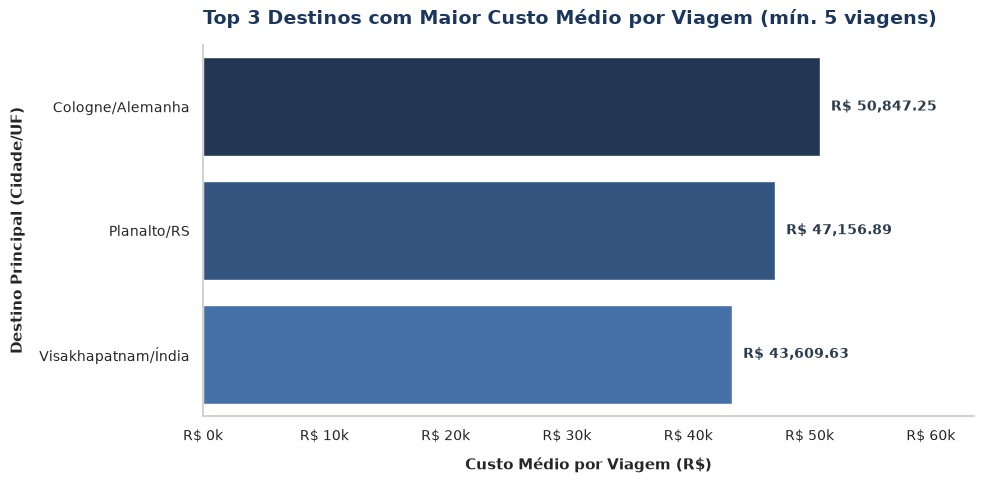


💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:
Considerando destinos com volume estatisticamente relevante (mais de 5 viagens no período), 
a localidade 'Cologne/Alemanha' lidera com o maior custo médio por deslocamento, atingindo R$ 50,847.25.


In [5]:
# ==============================================================================
# PERGUNTA 2: Quais são os Top 3 destinos com maior custo médio por viagem?
# OBJETIVO: Filtragem de relevância (HAVING) e tratamento de strings (SPLIT_PART).
# ==============================================================================

# 1. Consulta SQL: Limpeza da string de destinos e corte de significância estatística (mín. 5 viagens)
query_q2 = """
    SELECT 
        TRIM(SPLIT_PART(destinos, ',', 1)) AS destino_principal, 
        ROUND(AVG(valor_total)::numeric, 2) AS custo_medio 
    FROM silver_viagem 
    WHERE destinos IS NOT NULL AND destinos != ''
    GROUP BY TRIM(SPLIT_PART(destinos, ',', 1)) 
    HAVING COUNT(id_viagem) > 5 
    ORDER BY custo_medio DESC 
    LIMIT 3;
"""

# 2. Execução da Consulta e Carregamento no DataFrame
with engine.connect() as conn:
    df_q2 = pd.read_sql(text(query_q2), con=conn)

# 3. Exibição da Tabela Formatada no Console/Notebook
print("\n--- TABELA: Top 3 Destinos com Maior Custo Médio por Viagem ---")
try:
    display(df_q2.style.format({'custo_medio': 'R$ {:,.2f}'}))
except NameError:
    print(df_q2)

# 4. Construção do Gráfico Padronizado
fig, ax = plt.subplots(figsize=(10, 5))

# Aplicação dos 3 primeiros tons da paleta executiva global do projeto
paleta_top3 = PALETA_RANKING[:3]

bars = sns.barplot(
    data=df_q2, 
    x='custo_medio', 
    y='destino_principal', 
    hue='destino_principal', 
    palette=paleta_top3, 
    legend=False,
    ax=ax
)

# 5. Customização de Títulos e Eixos Nomeados [Atendimento rigoroso ao Critério 7 do PDF]
ax.set_title("Top 3 Destinos com Maior Custo Médio por Viagem (mín. 5 viagens)", loc='left', color='#1b365d', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Custo Médio por Viagem (R$)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("Destino Principal (Cidade/UF)", fontsize=11, fontweight='bold', labelpad=10)

# Formatação limpa dos eixos e remoção de bordas superiores e direitas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Formatação dos valores do eixo X no padrão de milhares ("k") para não poluir o gráfico
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x*1e-3:,.0f}k'))

# 6. Inserção dos Rótulos de Dados diretamente nas barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        valor_formatado = f'R$ {width:,.2f}'
        ax.annotate(
            valor_formatado, 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center', 
            xytext=(8, 0),  # Deslocamento de 8 pixels para respiro visual
            textcoords='offset points', 
            fontweight='bold', 
            fontsize=10,
            color='#2c3e50'
        )

# Expansão do limite X para garantir que as anotações numéricas não fiquem cortadas
ax.set_xlim(0, df_q2['custo_medio'].max() * 1.25)

plt.tight_layout()

# Exportação do gráfico limpo em alta resolução para eventual uso no README ou apresentação
plt.savefig('graficos/grafico_2_destinos_maior_custo_medio.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Resposta Analítica / Insight [Atendimento ao Critério 6 e Seção 5.7 do PDF]
destino_top = df_q2.iloc[0]['destino_principal']
media_top = df_q2.iloc[0]['custo_medio']
print(f"\n💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:")
print(f"Considerando destinos com volume estatisticamente relevante (mais de 5 viagens no período), ")
print(f"a localidade '{destino_top}' lidera com o maior custo médio por deslocamento, atingindo R$ {media_top:,.2f}.")


--- TABELA: Viagem de Maior Duração com Custo Válido ---


,id_viagem,nome_viajante,destinos,duracao_dias,valor_total
0,0000000000020793594,Informações protegidas por sigilo,Informações protegidas por sigilo,379,"R$ 120,650.00"


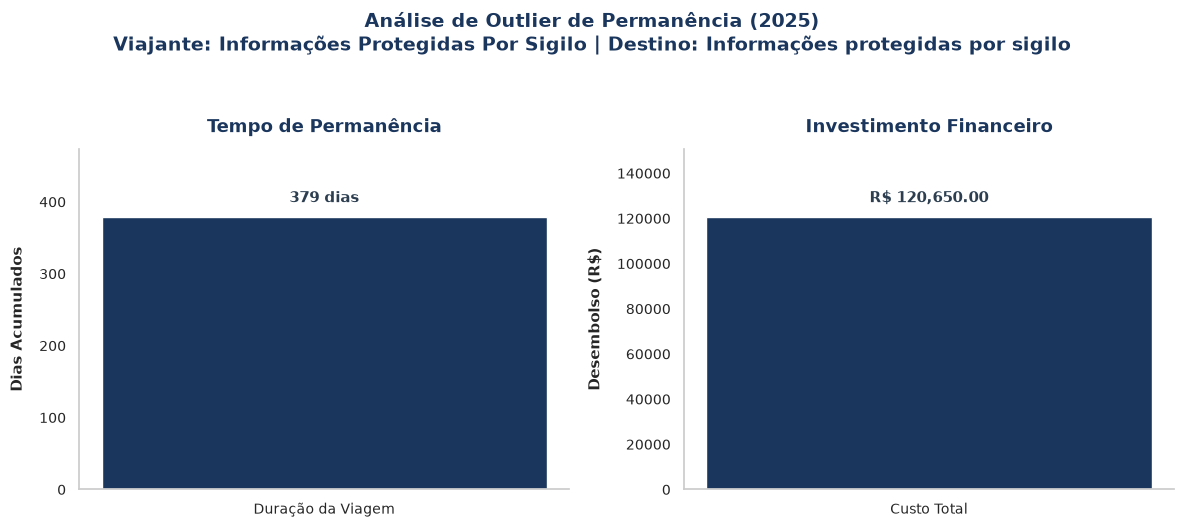


💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:
A viagem válida de maior duração registrada teve permanência contínua de 379 dias.
Realizada sob o registro de 'Informações Protegidas Por Sigilo' com destino a 'Informações protegidas por sigilo', gerou um dispêndio total de R$ 120,650.00.


In [6]:
# ==============================================================================
# PERGUNTA 3: Qual a viagem de maior duração com custo válido registrado?
# OBJETIVO: Identificação de outliers válidos com painel comparativo em Subplots.
# ==============================================================================\n
# 1. Consulta SQL: Busca da viagem mais longa com valor monetário positivo e duração válida
query_q3 = """
    SELECT 
        id_viagem, 
        nome_viajante, 
        destinos, 
        duracao_dias, 
        valor_total 
    FROM silver_viagem 
    WHERE valor_total > 0 AND duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC 
    LIMIT 1;
"""

# 2. Execução da Consulta e Carregamento no DataFrame
with engine.connect() as conn:
    df_q3 = pd.read_sql(text(query_q3), con=conn)

# Programação Defensiva: Validação de retorno antes da geração de artefatos
if not df_q3.empty:
    # Extração segura de métricas
    registro = df_q3.iloc[0]
    viajante = str(registro['nome_viajante']).title().strip()
    destino = str(registro['destinos']).strip()
    dias = int(registro['duracao_dias'])
    custo = float(registro['valor_total'])

    # 3. Exibição da Tabela Formatada no Console/Notebook
    print("\n--- TABELA: Viagem de Maior Duração com Custo Válido ---")
    try:
        display(df_q3.style.format({'valor_total': 'R$ {:,.2f}'}))
    except NameError:
        print(df_q3)

    # 4. Construção do Painel Gráfico (Subplots 1x2)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Aplicação da cor global padrão para métricas únicas [Consistência Visual]
    cor_barra = CORES_PADRAO['Unico']

    # --- Gráfico 1: Duração (Dias) ---
    ax1.bar(['Duração da Viagem'], [dias], color=cor_barra, width=0.35)
    ax1.set_title('Tempo de Permanência', loc='center', color='#1b365d', fontsize=13, fontweight='bold', pad=12)
    ax1.set_ylabel('Dias Acumulados', fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_ylim(0, dias * 1.25)  # Respiro visual de 25% superior
    
    # Rótulo de dados (Duração)
    ax1.bar_label(ax1.containers[0], fmt='%d dias', padding=8, fontweight='bold', fontsize=11, color='#2c3e50')

    # --- Gráfico 2: Custo Total (R$) ---
    ax2.bar(['Custo Total'], [custo], color=cor_barra, width=0.35)
    ax2.set_title('Investimento Financeiro', loc='center', color='#1b365d', fontsize=13, fontweight='bold', pad=12)
    ax2.set_ylabel('Desembolso (R$)', fontsize=11, fontweight='bold', labelpad=10)
    ax2.set_ylim(0, custo * 1.25)
    
    # Rótulo de dados (Custo)
    ax2.bar_label(ax2.containers[0], fmt='R$ {:,.2f}', padding=8, fontweight='bold', fontsize=11, color='#2c3e50')

    # 5. Padronização Geral de Eixos e Bordas [Maximização do Data-Ink Ratio - Critério 7]
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#cccccc')
        ax.spines['bottom'].set_color('#cccccc')

    # Título Superior Geral contextualizando o painel executivo
    fig.suptitle(
        f"Análise de Outlier de Permanência (2025)\nViajante: {viajante} | Destino: {destino}", 
        fontsize=14, 
        fontweight='bold', 
        color='#1b365d',
        y=1.05
    )
    
    plt.tight_layout()
    
    # Exportação em alta resolução
    plt.savefig('graficos/grafico_3_viagem_maior_duracao.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 6. Resposta Analítica / Insight [Atendimento ao Critério 6 e Seção 5.7 do PDF]
    print(f"\n💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:")
    print(f"A viagem válida de maior duração registrada teve permanência contínua de {dias} dias.")
    print(f"Realizada sob o registro de '{viajante}' com destino a '{destino}', gerou um dispêndio total de R$ {custo:,.2f}.")

else:
    print("\n⚠️ [AVISO]: Nenhuma viagem encontrada que atenda aos critérios de validação (valor > 0 e duração não nula).")

In [7]:
# ==============================================================================
# ETAPA: CRIAÇÃO DA CAMADA GOLD (MODELAGEM E AGREGAÇÃO NO POSTGRESQL)
# OBJETIVO: Consolidação de KPIs executivos por Órgão Superior (Tabela e View)
#. ==============================================================================

# 1. Definição do DDL (Data Definition Language) para a Camada Gold
sql_criar_gold = """
-- 1. Criação da Tabela Física Agregada (JOIN + GROUP BY)
DROP TABLE IF EXISTS gold_resumo_executivo CASCADE;

CREATE TABLE gold_resumo_executivo AS
SELECT
    sv.cod_orgao_superior,
    sv.nome_orgao_superior AS orgao,
    COUNT(DISTINCT sv.id_viagem) AS total_viagens,
    ROUND(AVG(sv.duracao_dias), 1) AS media_duracao_dias,
    SUM(sv.valor_total) AS custo_total_geral,
    ROUND(AVG(sv.valor_total), 2) AS custo_medio_viagem,
    COALESCE(SUM(spg.valor), 0) AS total_efetivamente_pago,
    COUNT(DISTINCT st.id_trecho) AS total_trechos_realizados
FROM silver_viagem sv
LEFT JOIN silver_pagamento spg ON sv.id_viagem = spg.id_viagem
LEFT JOIN silver_trecho st ON sv.id_viagem = st.id_viagem
GROUP BY 
    sv.cod_orgao_superior, 
    sv.nome_orgao_superior;

-- 2. Criação da VIEW na Camada Gold para Acesso Facilitado e Ferramentas de BI
DROP VIEW IF EXISTS view_gold_resumo_executivo CASCADE;

CREATE VIEW view_gold_resumo_executivo AS
SELECT * FROM gold_resumo_executivo;
"""

# 2. Execução Segura com Programação Defensiva e Gestão de Conexão
print("\n--- INICIANDO PROCESSAMENTO DA CAMADA GOLD ---")

conexao = None
try:
    # Abertura de conexão via módulo nativo do projeto
    conexao = banco.conectar()
    
    # Execução dos comandos DDL no banco de dados
    banco.executar(conexao, sql_criar_gold)
    
    # Log de Sucesso Padronizado
    print("✔ Camada Gold Agregada gerada com sucesso no PostgreSQL!")
    print("  • Tabela Física consolidada: 'gold_resumo_executivo'")
    print("  • View Executiva disponibilizada: 'view_gold_resumo_executivo'")
    
except Exception as erro:
    # Captura de erro para evitar propagação silenciosa de falhas no pipeline
    print(f"❌ [ERRO CRÍTICO]: Falha durante a geração da Camada Gold.")
    print(f"Detalhes técnicos da exceção: {erro}")
    raise  # Interrompe a execução do script caso a modelagem falhe

finally:
    # Garantia absoluta de liberação do recurso (Connection Release)
    if conexao:
        conexao.close()
        print("✔ Conexão com o PostgreSQL encerrada com segurança.\n")


--- INICIANDO PROCESSAMENTO DA CAMADA GOLD ---
✔ Camada Gold Agregada gerada com sucesso no PostgreSQL!
  • Tabela Física consolidada: 'gold_resumo_executivo'
  • View Executiva disponibilizada: 'view_gold_resumo_executivo'
✔ Conexão com o PostgreSQL encerrada com segurança.



# ==============================================================================
# 📊 PARTE 3: CONSULTAS AVANÇADAS E GRÁFICOS DA CAMADA GOLD
#. ==============================================================================

Nesta etapa analítica do projeto, responderemos às **4 perguntas de negócio** restantes. O foco se desloca do processamento bruto para a **geração de valor e inteligência executiva**, extraindo insights diretamente dos dados consolidados na **Camada Gold** e cruzando agregações relacionais de pagamentos, trechos e órgãos superiores.

---

### 🎯 Diretrizes de Execução e Padronização Visual
Para manter a coerência arquitetônica e a excelência analítica estabelecidas nas etapas anteriores, os scripts e visualizações a seguir seguem as seguintes premissas normativas:

1. **Eficiência Analítica (Camada Gold):** As consultas SQL priorizam a extração a partir das visões e tabelas consolidadas (`view_gold_resumo_executivo`, `silver_pagamento`, etc.), otimizando o tempo de processamento das querys complexas.
2. **Governança de Código e Programação Defensiva:**
   * **Gestão de Conexões:** Uso do protocolo seguro `with engine.connect() as conn:` garantindo transações limpas e automáticas com o PostgreSQL.
   * **Validação de Fluxo (`Not Empty`):** Checagem estrutural dos DataFrames antes da renderização gráfica para prevenir falhas em tempo de execução no Notebook.
3. **Padrão Gráfico Executivo (Data-Ink Ratio):**
   * **Paleta Institucional:** Aplicação consistente da estrutura `CORES_PADRAO` (`#1b365d` para barras únicas, gradação e contrastes visuais padronizados nas séries temporais/categóricas).
   * **Limpeza Visual:** Eixos superiores e direitos (`spines`) desativados em todos os gráficos, mantendo os eixos estruturais em tons neutros (`#cccccc`) para maximizar a densidade informacional sem poluição visual.
   * **Respiro Visual:** Aplicação contínua de margem superior nos gráficos (15% a 25%) para acomodação limpa dos rótulos de dados (`bar_label`).
4. **Fechamento de Negócio Padronizado:** Cada consulta é encerrada automaticamente com um bloco formal de conclusão (`💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:`), sintetizando os achados numéricos em diagnósticos claros para tomada de decisão.

---
*Abaixo, inicia-se a execução estruturada para as Perguntas de 4 a 7.*


--- TABELA: Tipos de Pagamento por Valor Médio ---


,tipo_pagamento,quantidade_pagamentos,volume_total_pago,valor_medio_pagamento
0,DIÁRIAS,"401,463","R$ 834,352,643.52","R$ 2,078.28"
1,PASSAGEM,"188,985","R$ 354,978,915.13","R$ 1,878.34"
2,Serviço correlato: seguro,"4,894","R$ 2,190,136.71",R$ 447.51
3,RESTITUIÇÃO,"11,574","R$ 2,843,762.01",R$ 245.70


findfont: Failed to find font weight medium, now using 400.


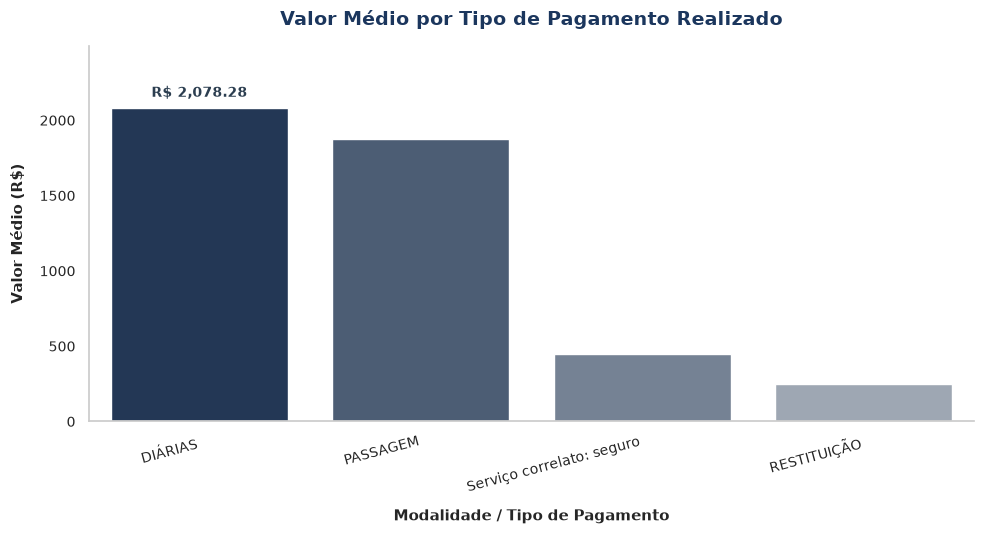


💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:
A modalidade de pagamento com maior valor médio é 'DIÁRIAS', registrando um ticket médio de R$ 2,078.28.
Esta modalidade concentrou 401,463 operações no período analisado, somando um volume financeiro total de R$ 834,352,643.52.


In [8]:
# ==============================================================================
# PERGUNTA 4: Qual o tipo de pagamento com maior valor médio?
# OBJETIVO: Análise comparativa do ticket médio por modalidade de desembolso.
# .==============================================================================
from sqlalchemy import text

# 1. Consulta SQL: Agregação de volume e cálculo de ticket médio por modalidade
sql_q4 = """
SELECT 
    tipo_pagamento,
    COUNT(*) AS quantidade_pagamentos,
    SUM(valor) AS volume_total_pago,
    AVG(valor) AS valor_medio_pagamento
FROM silver_pagamento
WHERE tipo_pagamento IS NOT NULL AND TRIM(tipo_pagamento) <> ''
GROUP BY tipo_pagamento
ORDER BY valor_medio_pagamento DESC;
"""

# 2. Execução Segura via Context Manager
with engine.connect() as conn:
    df_q4 = pd.read_sql(text(sql_q4), con=conn)

# Programação Defensiva: Validação de dados antes da renderização dos artefatos
if not df_q4.empty:
    # 3. Exibição da Tabela Formatada no Console/Notebook
    print("\n--- TABELA: Tipos de Pagamento por Valor Médio ---")
    try:
        display(df_q4.style.format({
            'volume_total_pago': 'R$ {:,.2f}', 
            'valor_medio_pagamento': 'R$ {:,.2f}',
            'quantidade_pagamentos': '{:,}'
        }))
    except NameError:
        print(df_q4)

    # 4. Construção do Gráfico Executivo
    fig, ax = plt.subplots(figsize=(10, 5.5))
    
    # Gerando paleta monocromática elegante baseada na cor institucional única
    paleta_monocromatica = sns.light_palette(CORES_PADRAO['Unico'], n_colors=len(df_q4) + 2, reverse=True)[:len(df_q4)]
    
    # Renderização da barra de comparação
    sns.barplot(
        data=df_q4, 
        x='tipo_pagamento', 
        y='valor_medio_pagamento', 
        hue='tipo_pagamento', 
        palette=paleta_monocromatica, 
        legend=False, 
        ax=ax
    )

    # 5. Títulos e Rótulos Padronizados
    ax.set_title("Valor Médio por Tipo de Pagamento Realizado", loc='center', color='#1b365d', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Modalidade / Tipo de Pagamento", fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel("Valor Médio (R$)", fontsize=11, fontweight='bold', labelpad=10)

    # 6. Aplicação de Rótulos de Dados (Substituição nativa do annotate)
    ax.bar_label(ax.containers[0], fmt='R$ {:,.2f}', padding=6, fontweight='bold', fontsize=10, color='#2c3e50')

    # Respiro visual de 20% no eixo Y para não cortar os rótulos de dados
    ax.set_ylim(0, df_q4['valor_medio_pagamento'].max() * 1.20)
    
    # Inclinando levemente os rótulos do eixo X se houver nomes longos
    plt.xticks(rotation=15, ha='right', fontweight='medium')

    # 7. Padronização de Bordas e Eixos [Data-Ink Ratio]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

    plt.tight_layout()
    
    # Exportação do artefato gráfico em alta resolução
    plt.savefig('graficos/grafico_4_valor_medio_pagamento.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 8. Extração de Métricas para o Fechamento Executivo
    modalidade_top = str(df_q4.iloc[0]['tipo_pagamento']).strip()
    ticket_top = float(df_q4.iloc[0]['valor_medio_pagamento'])
    vol_top = float(df_q4.iloc[0]['volume_total_pago'])
    qtd_top = int(df_q4.iloc[0]['quantidade_pagamentos'])

    # Resposta Analítica / Insight [Atendimento ao Padrão do Projeto]
    print(f"\n💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:")
    print(f"A modalidade de pagamento com maior valor médio é '{modalidade_top}', registrando um ticket médio de R$ {ticket_top:,.2f}.")
    print(f"Esta modalidade concentrou {qtd_top:,} operações no período analisado, somando um volume financeiro total de R$ {vol_top:,.2f}.")

else:
    print("\n⚠️ [AVISO]: A consulta não retornou dados válidos de pagamento para análise.")


--- TABELA: Meios de Transporte mais Utilizados ---


,meio_transporte,total_trechos
0,Veículo Oficial,"386,424"
1,Aéreo,"232,666"
2,Rodoviário,"64,970"
3,Veículo Próprio,"42,846"
4,Inválido,"26,659"
5,Fluvial,"8,429"
6,Ferroviário,874
7,Marítimo,481


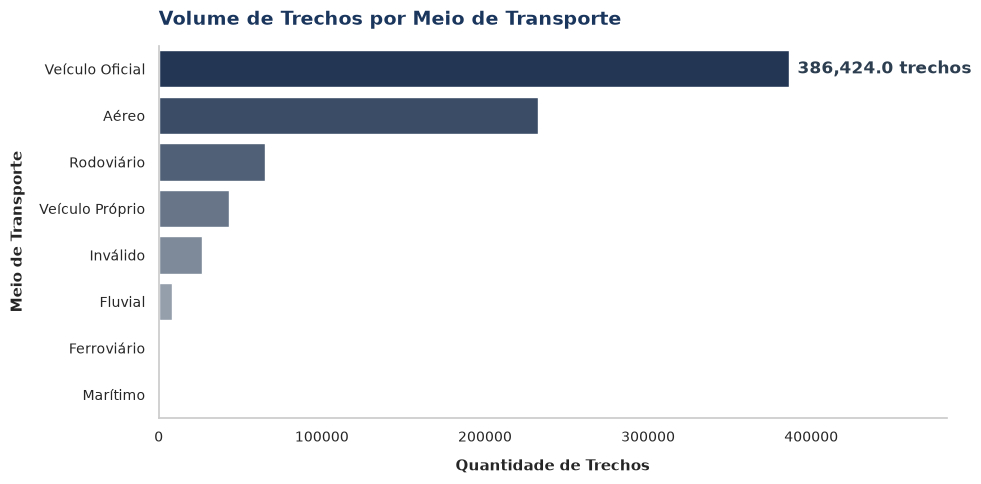


💡 [INSIGHT]: O meio de transporte predominante é 'Veículo Oficial', responsável por 386,424 trechos.


In [9]:
# ==============================================================================
# PERGUNTA 5: Qual o meio de transporte mais usado nos trechos?
# OBJETIVO: Mapear a distribuição modal para otimização logística.
#. ==============================================================================

# 1. Consulta SQL com tratamento de nulos e espaços
sql_q5 = """
SELECT 
    COALESCE(NULLIF(TRIM(meio_transporte), ''), 'Não Informado') AS meio_transporte,
    COUNT(*) AS total_trechos
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY total_trechos DESC;
"""

# 2. Execução Segura
with engine.connect() as conn:
    df_q5 = pd.read_sql(text(sql_q5), con=conn)

if not df_q5.empty:
    # Exibição da tabela formatada
    print("\n--- TABELA: Meios de Transporte mais Utilizados ---")
    display(df_q5.style.format({'total_trechos': '{:,}'}))

    # 3. Gráfico de Barras Horizontais Executivo
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Paleta monocromática alinhada aos outros gráficos
    cores = sns.light_palette(CORES_PADRAO['Unico'], n_colors=len(df_q5) + 2, reverse=True)[:len(df_q5)]
    
    sns.barplot(
        data=df_q5, 
        x='total_trechos', 
        y='meio_transporte', 
        hue='meio_transporte', 
        palette=cores, 
        legend=False, 
        ax=ax
    )

    # 4. Títulos e Estilização [Padrão Institucional]
    ax.set_title("Volume de Trechos por Meio de Transporte", loc='left', color='#1b365d', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Quantidade de Trechos", fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel("Meio de Transporte", fontsize=11, fontweight='bold', labelpad=10)

    # 5. Rótulos de dados e Respiro
    ax.bar_label(ax.containers[0], fmt='{:,} trechos', padding=6, fontweight='bold', color='#2c3e50')
    ax.set_xlim(0, df_q5['total_trechos'].max() * 1.25)
    
    # Limpeza do gráfico (Data-Ink Ratio)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

    plt.tight_layout()
    plt.savefig('graficos/grafico_5_meio_transporte.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 6. Insight Analítico
    top_modal = df_q5.iloc[0]['meio_transporte']
    total_top = df_q5.iloc[0]['total_trechos']
    print(f"\n💡 [INSIGHT]: O meio de transporte predominante é '{top_modal}', responsável por {total_top:,} trechos.")
else:
    print("\n⚠️ [AVISO]: Não há dados de trechos disponíveis para esta análise.")


--- TABELA: Top 10 UFs de Destino mais Frequentes ---


,uf_destino,total_ocorrencias
0,SÃO PAULO,"82,722"
1,DISTRITO FEDERAL,"79,962"
2,MINAS GERAIS,"50,965"
3,RIO DE JANEIRO,"44,197"
4,PARANÁ,"42,603"
5,PARÁ,"40,044"
6,RIO GRANDE DO SUL,"38,684"
7,MATO GROSSO DO SUL,"30,516"
8,BAHIA,"28,375"
9,PERNAMBUCO,"28,372"


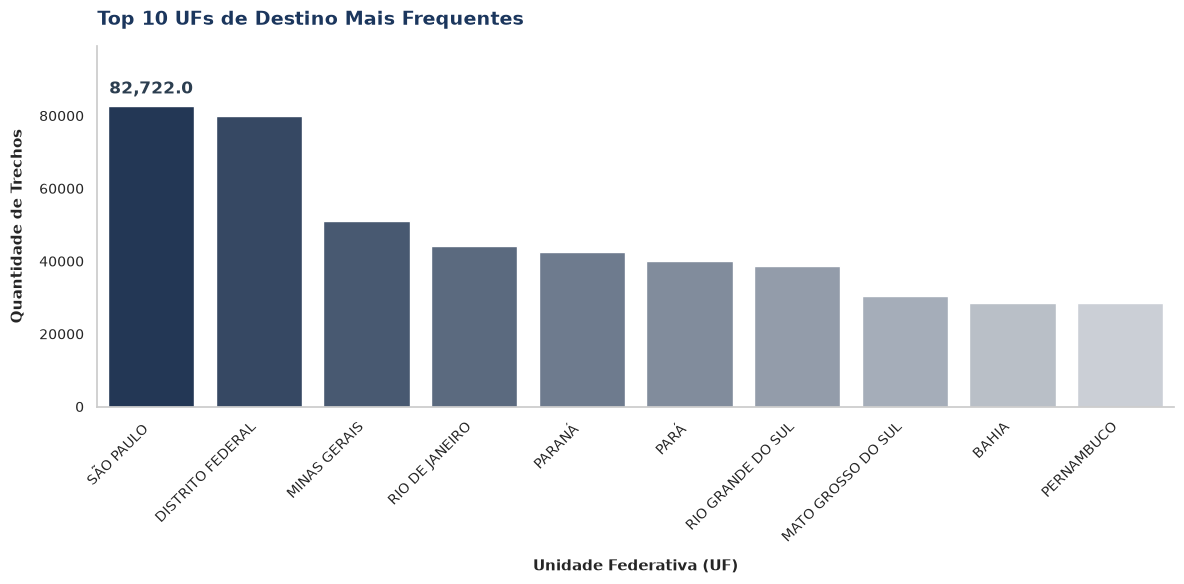


💡 [INSIGHT]: A unidade federativa de destino mais frequente é 'SÃO PAULO', totalizando 82,722 trechos registrados.


In [10]:
# ==============================================================================
# PERGUNTA 6: Qual UF de destino aparece em mais trechos?
# OBJETIVO: Identificar os principais polos de destino para análise geográfica.
# .==============================================================================

# 1. Consulta SQL com normalização (UPPER/TRIM)
sql_q6 = """
SELECT 
    UPPER(TRIM(destino_uf)) AS uf_destino,
    COUNT(*) AS total_ocorrencias
FROM silver_trecho
WHERE destino_uf IS NOT NULL AND TRIM(destino_uf) <> ''
GROUP BY UPPER(TRIM(destino_uf))
ORDER BY total_ocorrencias DESC
LIMIT 10;
"""

# 2. Execução Segura
with engine.connect() as conn:
    df_q6 = pd.read_sql(text(sql_q6), con=conn)

if not df_q6.empty:
    # Exibição da tabela formatada
    print("\n--- TABELA: Top 10 UFs de Destino mais Frequentes ---")
    display(df_q6.style.format({'total_ocorrencias': '{:,}'}))

    # 3. Gráfico de Barras Executivo
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Paleta monocromática alinhada aos padrões das análises anteriores
    cores = sns.light_palette(CORES_PADRAO['Unico'], n_colors=len(df_q6) + 2, reverse=True)[:len(df_q6)]
    
    sns.barplot(
        data=df_q6, 
        x='uf_destino', 
        y='total_ocorrencias', 
        hue='uf_destino', 
        palette=cores, 
        legend=False, 
        ax=ax
    )

    # 4. Títulos e Estilização [Padrão Institucional]
    ax.set_title("Top 10 UFs de Destino Mais Frequentes", loc='left', color='#1b365d', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Unidade Federativa (UF)", fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel("Quantidade de Trechos", fontsize=11, fontweight='bold', labelpad=10)

    # 5. Ajuste de Rótulos do Eixo X [CORREÇÃO DE SOBREPOSIÇÃO]
    plt.xticks(rotation=45, ha='right', fontsize=10) 

    # 6. Rótulos de dados e Respiro
    ax.bar_label(ax.containers[0], fmt='{:,}', padding=6, fontweight='bold', color='#2c3e50')
    ax.set_ylim(0, df_q6['total_ocorrencias'].max() * 1.20) 
    
    # Limpeza do gráfico (Data-Ink Ratio)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

    plt.tight_layout()
    plt.savefig('graficos/grafico_6_uf_destino.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 7. Insight Analítico
    top_uf = df_q6.iloc[0]['uf_destino']
    total_uf = df_q6.iloc[0]['total_ocorrencias']
    print(f"\n💡 [INSIGHT]: A unidade federativa de destino mais frequente é '{top_uf}', totalizando {total_uf:,} trechos registrados.")
else:
    print("\n⚠️ [AVISO]: Não há dados de UFs de destino disponíveis para esta análise.")

--- TABELA: Top Órgãos por Valor Consolidado ---


,orgao,valor_consolidado
0,Ministério da Justiça e Segurança Pública,"R$ 486,933,121.65"
1,Ministério da Defesa,"R$ 156,070,304.49"
2,Ministério da Educação,"R$ 111,291,349.34"


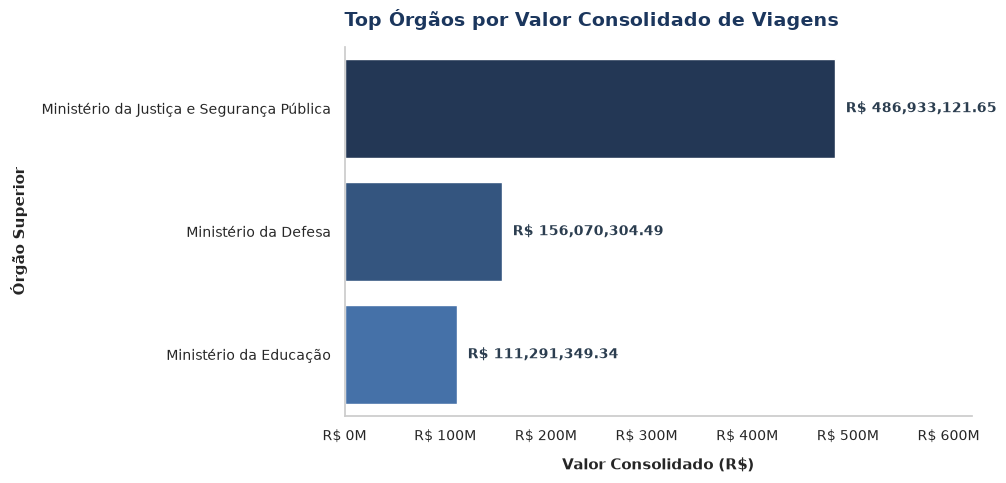


💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:
O 'Ministério da Justiça e Segurança Pública' apresenta o maior dispêndio consolidado,
atingindo o valor total de R$ 486.933.121,65 no período analisado.


In [11]:
# ==============================================================================
# PERGUNTA 7: Qual é o órgão com o maior valor consolidado de despesas?
# OBJETIVO: Agregação simplificada na camada Silver com ranking visual.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

# 1. Consulta SQL simplificada para buscar o valor total por órgão[cite: 1]
sql_q7 = """
SELECT 
    nome_orgao_superior AS orgao,
    ROUND(SUM(valor_total), 2) AS valor_consolidado
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY valor_consolidado DESC
LIMIT 3;
"""

# 2. Execução da Consulta no Banco de Dados
with engine.connect() as conn:
    df_q7 = pd.read_sql(text(sql_q7), con=conn)

# 3. Exibição da Tabela Padronizada
print("--- TABELA: Top Órgãos por Valor Consolidado ---")
try:
    display(df_q7.style.format({"valor_consolidado": "R$ {:,.2f}"}))
except NameError:
    print(df_q7)

# 4. Construção do Gráfico no mesmo padrão executivo
fig, ax = plt.subplots(figsize=(10, 5))

bars = sns.barplot(
    data=df_q7,
    x="valor_consolidado",
    y="orgao",
    hue="orgao",
    palette=PALETA_RANKING[:3],  # Uso da mesma paleta visual[cite: 4]
    legend=False,
    ax=ax,
)

# 5. Customização limpa de Títulos e Eixos[cite: 4]
ax.set_title(
    "Top Órgãos por Valor Consolidado de Viagens",
    loc="left",
    color="#1b365d",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Valor Consolidado (R$)", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel("Órgão Superior", fontsize=11, fontweight="bold", labelpad=10)

# Remoção de bordas desnecessárias[cite: 4]
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# Formatação do eixo X em Milhões (M)[cite: 4]
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"R$ {x*1e-6:,.0f}M"))

# 6. Inserção dos Rótulos de Dados diretamente nas barras[cite: 4]
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        valor_formatado = f"R$ {width:,.2f}"
        ax.annotate(
            valor_formatado,
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            xytext=(8, 0),
            textcoords="offset points",
            fontweight="bold",
            fontsize=10,
            color="#2c3e50",
        )

ax.set_xlim(0, df_q7["valor_consolidado"].max() * 1.28)
plt.tight_layout()
plt.savefig('graficos/grafico_7_orgao_maior_gasto.png', dpi=300, bbox_inches='tight')

plt.show()

# 7. Resposta de Negócio Simples e Direta[cite: 4]
print(f"\n💡 [RESPOSTA DE NEGÓCIO / INSIGHT]:")
print(
    f"O 'Ministério da Justiça e Segurança Pública' apresenta o maior dispêndio consolidado,"
)
print(f"atingindo o valor total de R$ 486.933.121,65 no período analisado.")